# Self-Supervised Learning mit ResNet-18 auf 8bit-ERP-Bildern

Dieses Notebook implementiert eine kleine End-to-End-Pipeline fuer Self-Supervised Learning auf echten ERP-Bildern aus dem 8bit-Gameplay-Datensatz des Papers von Cavanagh & Castellanos (2016).

Pipeline:
- OpenNeuro `ds003517` (`sub-001`) in den `week_15`-Ordner laden
- die kontinuierlichen EEG-Daten in ein Julia-freundliches HDF5/CSV-Format umwandeln
- daraus unlabelled ERP-Bilder fuer Contrastive Learning aufbauen
- ein **nicht vortrainiertes** `ResNet(18)`-Backbone mit SimCLR trainieren
- die gelernten Features auf den bereits vorhandenen gelabelten Fixations-ERP-Bildern evaluieren


## Quellen

- Metalhead ResNet API: https://fluxml.ai/Metalhead.jl/stable/api/resnet/
- SimCLR: https://proceedings.mlr.press/v119/chen20j.html
- OpenNeuro Datensatz `ds003517`: https://doi.org/10.18112/openneuro.ds003517.v1.1.0
- Paper: https://doi.org/10.1016/j.neuroimage.2016.02.075

Wichtige Designentscheidung hier: Die ERP-Bilder bleiben **grayscale / 1-channel** und das ResNet wird mit `pretrain=false` direkt fuer diese Daten aufgebaut.


In [1]:
import Pkg

Pkg.activate(joinpath(pwd(), "..", "model_test"))
Pkg.instantiate()

using CSV
using CairoMakie
using CUDA
using DataFrames
using Flux
using Metalhead

include(joinpath(pwd(), "self_supervised_helpers.jl"))
using .Week15SelfSupervisedLearning

println("Flux version: ", Base.pkgversion(Flux))
println("Metalhead version: ", Base.pkgversion(Metalhead))
println("CUDA functional: ", CUDA.functional())
println("8bit derived dir: ", OPENNEURO_DERIVED_DIR)


  Activating project at `~/Dokumente/BA2/notebooks/model_test`


Flux version: 0.16.9
Metalhead version: 0.9.6
CUDA functional: true
8bit derived dir: /home/benjamin/Dokumente/BA2/notebooks/datasets/ds003517_sub001_derived


In [2]:
ensure_openneuro_8bit_dataset!()

event_counts_8bit = summarize_8bit_events()
event_counts_8bit


Row,run,trial_type,count
,Int64,String31,Int64
1,1,GAMBLING LOSS,17
2,1,GAMBLING WIN,18
3,1,ODDBALL RARE,41
4,1,ODDBALL STANDARD,159
5,2,COLLECT_AMMO,117
6,2,COLLECT_STAR,1228
7,2,MISSILE_HIT_ENEMY,766
8,2,PLAYER_CRASH_ENEMY,150
9,2,PLAYER_CRASH_WALL,247


In [3]:
IMAGE_SIZE = (64, 64)
APPLY_LOWPASS = true

unlabelled_8bit = load_8bit_unlabelled_cache(
    target_size = IMAGE_SIZE,
    lowpass = APPLY_LOWPASS,
)

labelled_fixations = load_fixation_binary_cache(
    target_size = IMAGE_SIZE,
    lowpass = APPLY_LOWPASS,
)

println("Unlabelled 8bit images: ", length(unlabelled_8bit.images))
println("Labeled fixation images: ", length(labelled_fixations.images))
println("8bit tensor size: ", size(unlabelled_8bit.tensor))
println("Fixation tensor size: ", size(labelled_fixations.tensor))

fixation_balance_df = combine(groupby(DataFrame(binary_label = labelled_fixations.labels), :binary_label), nrow => :count)
sort!(fixation_balance_df, :binary_label)

(event_counts_8bit = unlabelled_8bit.event_counts, fixation_balance_df = fixation_balance_df)


Unlabelled 8bit images: 2268
Labeled fixation images: 488
8bit tensor size: (64, 64, 1, 2268)
Fixation tensor size: (64, 64, 1, 488)


(event_counts_8bit = 10×2 DataFrame
 Row │ trial_type          n_images 
     │ String              Int64    
─────┼──────────────────────────────
   1 │ ODDBALL STANDARD         252
   2 │ ODDBALL RARE             252
   3 │ GAMBLING WIN             126
   4 │ GAMBLING LOSS            126
   5 │ SHOOT_BUTTON             252
   6 │ MISSILE_HIT_ENEMY        252
   7 │ COLLECT_STAR             252
   8 │ PLAYER_CRASH_ENEMY       252
   9 │ PLAYER_CRASH_WALL        252
  10 │ COLLECT_AMMO             252, fixation_balance_df = 2×2 DataFrame
 Row │ binary_label  count 
     │ Int64         Int64 
─────┼─────────────────────
   1 │            0    452
   2 │            1     36)

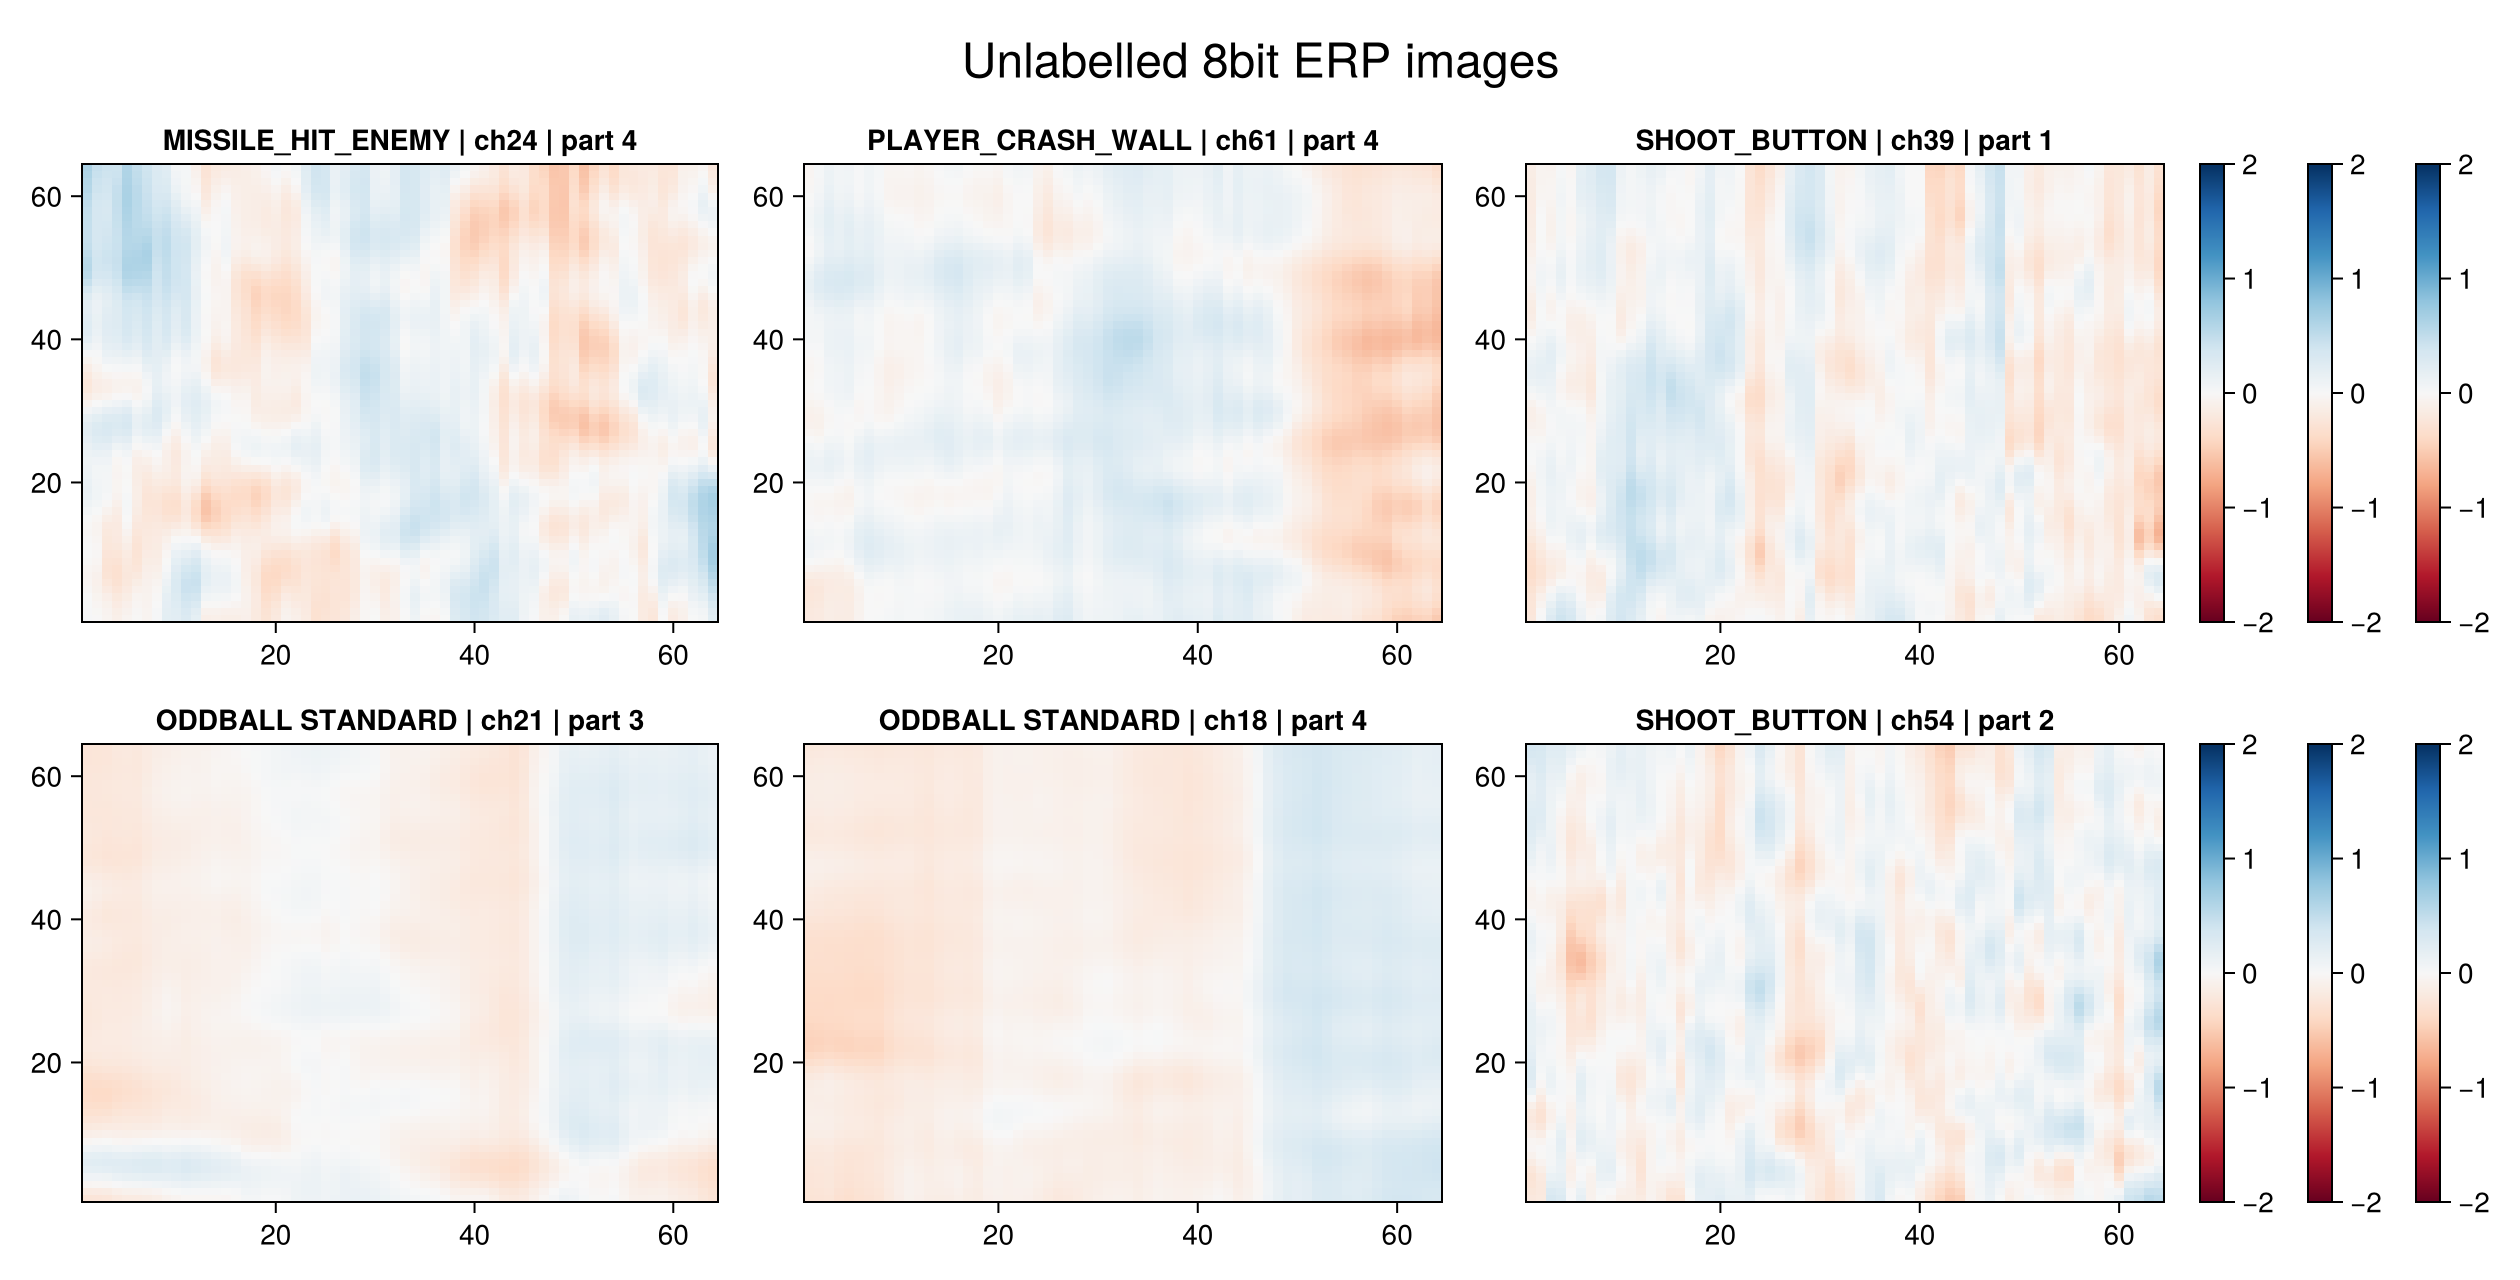

In [4]:
fig_unlabelled = plot_image_grid(unlabelled_8bit.images, unlabelled_8bit.meta; n = 6, title = "Unlabelled 8bit ERP images")
fig_unlabelled


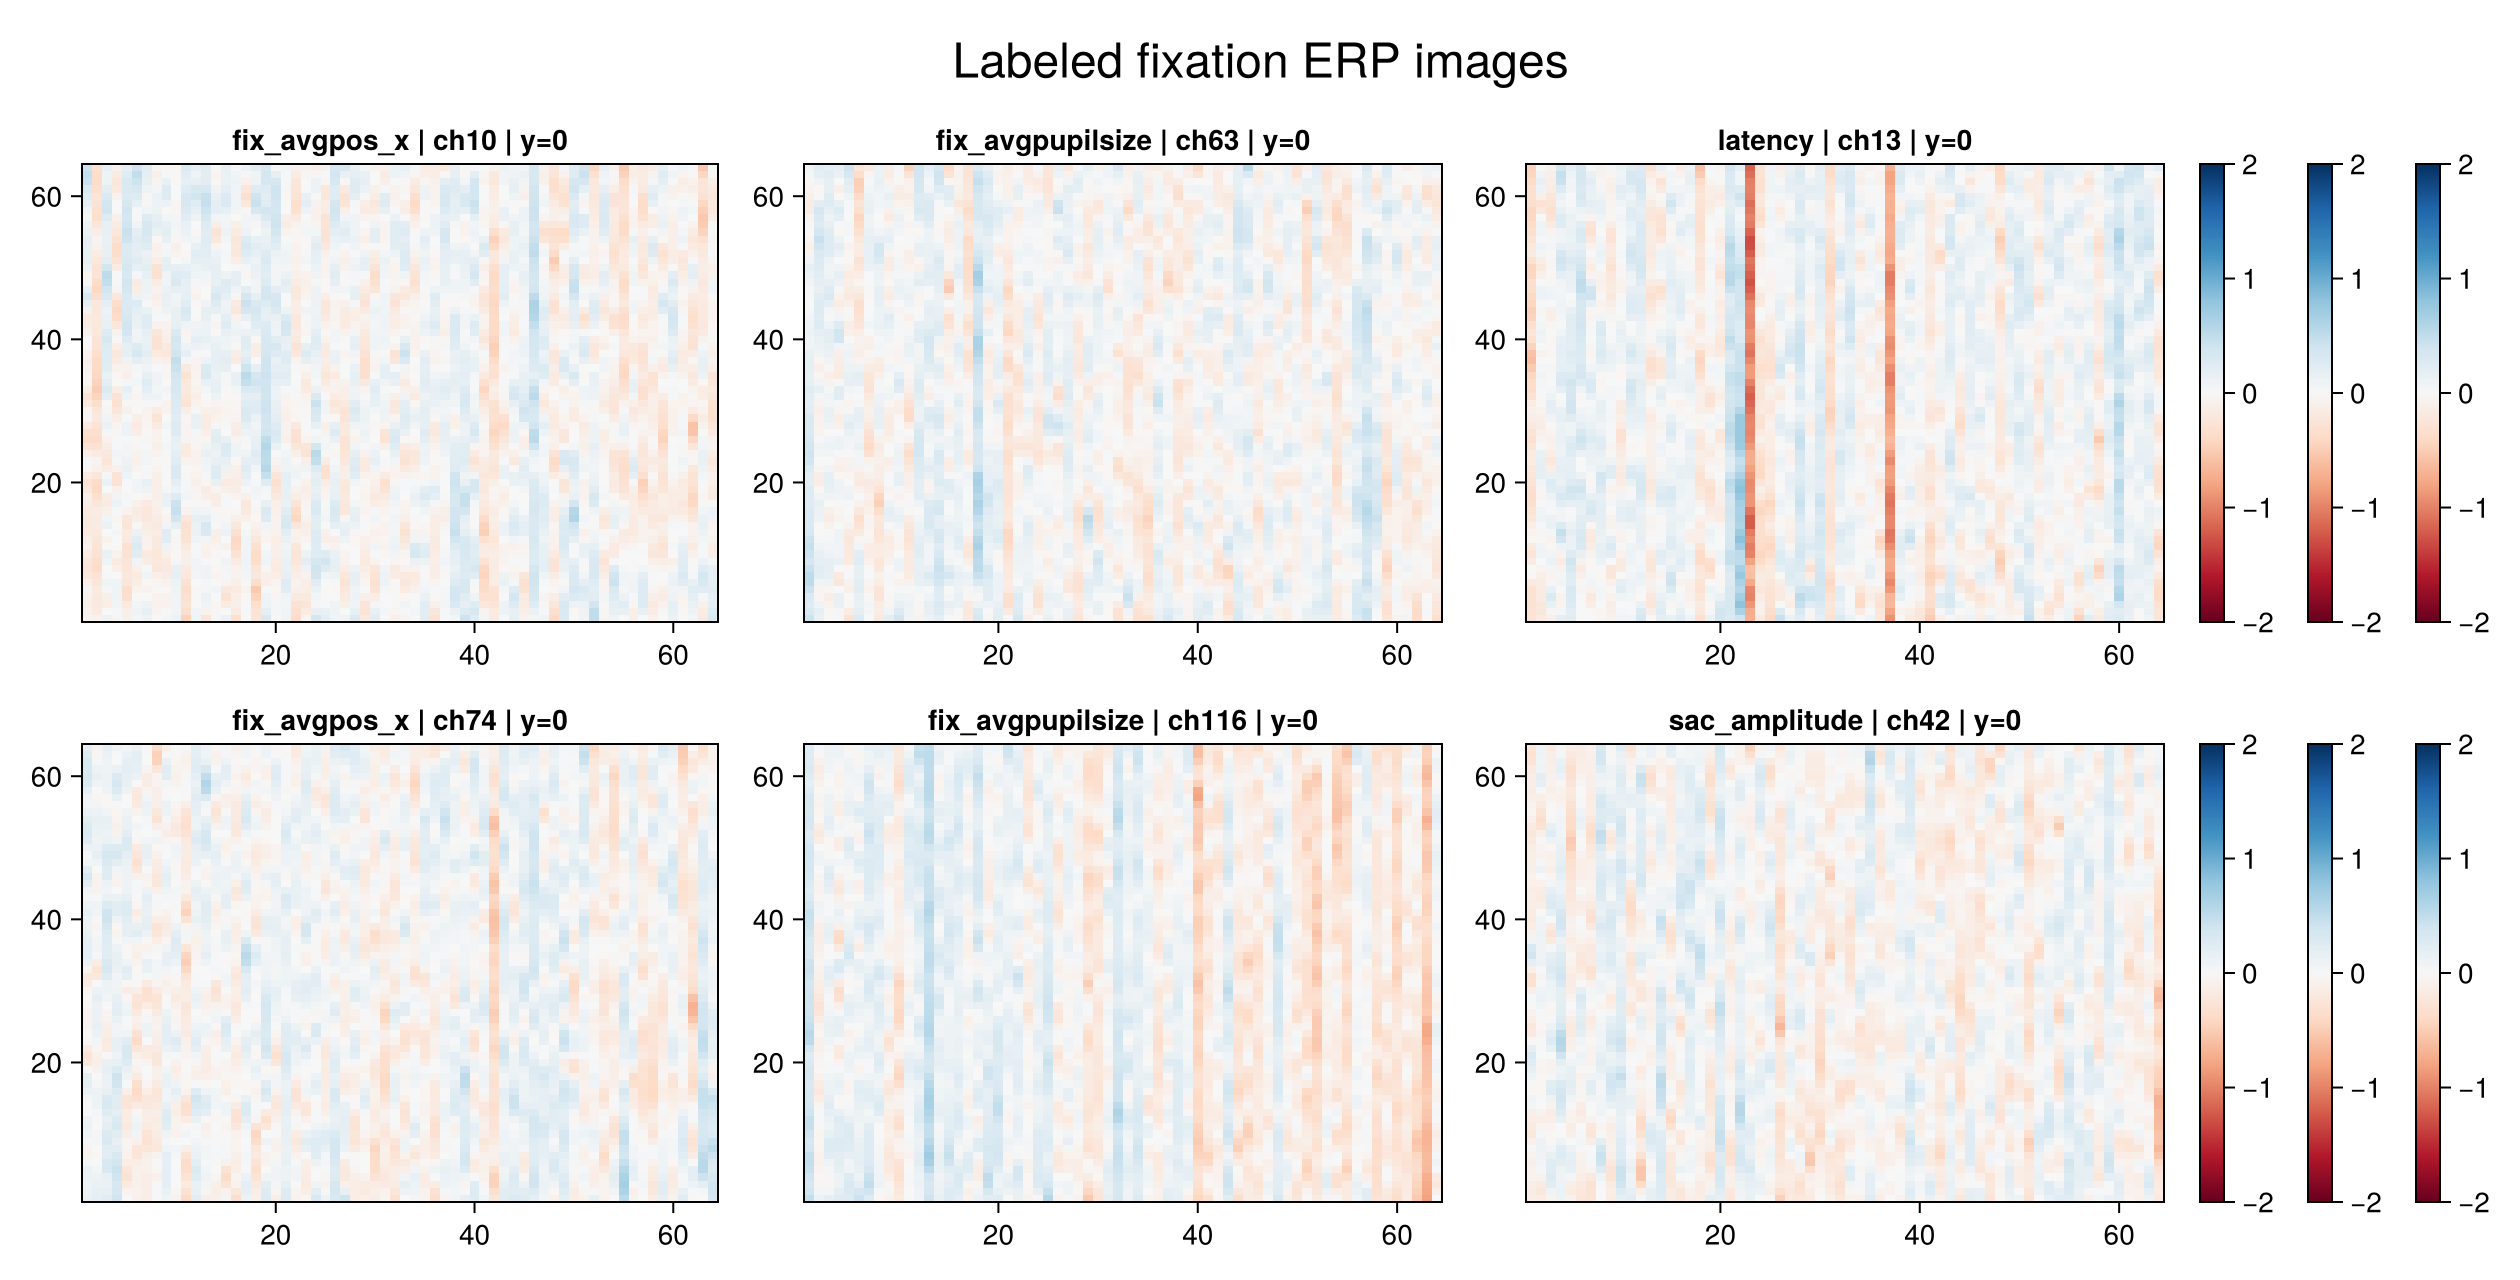

In [5]:
fig_labelled = plot_image_grid(labelled_fixations.images, labelled_fixations.meta; n = 6, title = "Labeled fixation ERP images")
fig_labelled


## Modell und Training

Das Self-Supervised-Modell verwendet SimCLR:
- zwei augmentierte Views desselben ERP-Bildes
- ein **nicht vortrainiertes** `Metalhead.ResNet(18; pretrain=false, inchannels=1, ...)`
- einen kleinen nichtlinearen Projektionskopf
- NT-Xent / Contrastive Loss

Danach werden drei Varianten auf dem gelabelten Fixationssatz verglichen:
- `baseline_resnet18`: gleicher ResNet-18, aber direkt supervised from scratch
- `ssl_linear_probe`: Encoder aus SimCLR einfrieren, nur den Klassifikationskopf trainieren
- `ssl_finetune`: Encoder aus SimCLR initialisieren und dann gemeinsam weitertrainieren


In [6]:
simclr_template = build_simclr_resnet18(in_channels = 1)
simclr_template.model


Chain(
  Chain(
    Chain(
      Chain(
        Conv((7, 7), 1 => 64, pad=3, stride=2, bias=false),  # 3_136 parameters
        BatchNorm(64, relu),            # 128 parameters, plus 128
        MaxPool((3, 3), pad=1, stride=2),
      ),
      Chain(
        Parallel(
          PartialFunction(
            "",
            Metalhead.addact,
            (NNlib.relu,),
            NamedTuple(),
          ),
          identity,
          Chain(
            Conv((3, 3), 64 => 64, pad=1, bias=false),  # 36_864 parameters
            BatchNorm(64),              # 128 parameters, plus 128
            NNlib.relu,
            Conv((3, 3), 64 => 64, pad=1, bias=false),  # 36_864 parameters
            BatchNorm(64),              # 128 parameters, plus 128
          ),
        ),
        Parallel(
          PartialFunction(
            "",
            Metalhead.addact,
            (NNlib.relu,),
            NamedTuple(),
          ),
          identity,
          Chain(
            Conv((3, 3), 64

In [ ]:
SSL_BATCHSIZE = CUDA.functional() ? 64 : 16
CLASSIFIER_BATCHSIZE = CUDA.functional() ? 32 : 8

SSL_EPOCHS = CUDA.functional() ? 8 : 2
BASELINE_EPOCHS = CUDA.functional() ? 6 : 2
PROBE_EPOCHS = CUDA.functional() ? 8 : 2
FINETUNE_EPOCHS = CUDA.functional() ? 6 : 2

transfer_run = run_transfer_experiment(
    image_size = IMAGE_SIZE,
    lowpass = APPLY_LOWPASS,
    ssl_batchsize = SSL_BATCHSIZE,
    ssl_epochs = SSL_EPOCHS,
    ssl_lr = 1f-3,
    ssl_temperature = 0.10f0,
    baseline_epochs = BASELINE_EPOCHS,
    baseline_lr = 1f-3,
    probe_epochs = PROBE_EPOCHS,
    probe_lr = 2f-3,
    finetune_epochs = FINETUNE_EPOCHS,
    finetune_lr = 3f-4,
    classifier_batchsize = CLASSIFIER_BATCHSIZE,
    seed = 20260317,
)

transfer_run.results_df


## Hinweise

- Die geklonten Rohdaten liegen unter `notebooks/datasets/ds003517`.
- Die abgeleiteten 8bit-Dateien liegen danach unter `notebooks/datasets/ds003517_sub001_derived`.
- Das Preprocessing-Skript ist `scripts/prepare_openneuro_8bit_dataset.py`.
- Die SimCLR-/ResNet-Helfer liegen in `notebooks/week_15/self_supervised_helpers.jl`.
- Wenn du spaeter laenger trainieren willst, erhoehe zuerst `SSL_EPOCHS`, danach `PROBE_EPOCHS` und `FINETUNE_EPOCHS`.
